In [1]:
import os
import re
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
def path_to_num(string):
    res = re.findall("structure_\d+_", string)[0]
    res = re.findall("\d+", res)[0]
    return int(res)


root = r"D:\inception_dataset\train"
header_names = ["structure_num", "young_module", "fem_volume_fraction"]

normal0_ym = pd.read_csv(os.path.join(root, "64_normal_0_young_modules.csv"), names=header_names)
normal15_ym = pd.read_csv(os.path.join(root, "64_normal_1.5_young_modules.csv"), names=header_names)
spheresRVE_ym = pd.read_csv(os.path.join(root, "64_spheresRVE_young_modules.csv"), names=header_names)
uniform05_ym = pd.read_csv(os.path.join(root, "64_uniform_0.5_young_modules.csv"), names=header_names)
uniform1_ym = pd.read_csv(os.path.join(root, "64_uniform_1_young_modules.csv"), names=header_names)

normal0_info = pd.read_csv(os.path.join(root, "info_64_normal_0.csv"))
normal15_info = pd.read_csv(os.path.join(root, "info_64_normal_1.5.csv"))
spheresRVE_info = pd.read_csv(os.path.join(root, "info_64_spheresRVE.csv"))
uniform05_info = pd.read_csv(os.path.join(root, "info_64_uniform_0.5.csv"))
uniform1_info = pd.read_csv(os.path.join(root, "info_64_uniform_1.csv"))

In [13]:
normal0_info["num"] = normal0_info.index.values
normal15_info["num"] = normal15_info.index.values
uniform05_info["num"] = uniform05_info.index.values
uniform1_info["num"] = uniform1_info.index.values

normal0_ym["structure_num"] = normal0_ym["structure_num"].apply(lambda x: path_to_num(x))
normal15_ym["structure_num"] = normal15_ym["structure_num"].apply(lambda x: path_to_num(x))
spheresRVE_ym["structure_num"] = spheresRVE_ym["structure_num"].apply(lambda x: path_to_num(x))
uniform05_ym["structure_num"] = uniform05_ym["structure_num"].apply(lambda x: path_to_num(x))
uniform1_ym["structure_num"] = uniform1_ym["structure_num"].apply(lambda x: path_to_num(x))

normal0_ym["class"] = "normal_0"
normal15_ym["class"] = "normal_1.5"
spheresRVE_ym["class"] = "spheres"
uniform05_ym["class"] = "uniform_0.5"
uniform1_ym["class"] = "uniform_1"

normal0_info = normal0_info.merge(normal0_ym, how="left", left_on="num", right_on="structure_num")
normal15_info = normal15_info.merge(normal15_ym, how="left", left_on="num", right_on="structure_num")
spheresRVE_info = spheresRVE_info.merge(spheresRVE_ym, how="left", left_on="idx", right_on="structure_num")
uniform05_info = uniform05_info.merge(uniform05_ym, how="left", left_on="num", right_on="structure_num")
uniform1_info = uniform1_info.merge(uniform1_ym, how="left", left_on="num", right_on="structure_num")

train_ds_info = pd.concat([normal0_info, normal15_info, spheresRVE_info, uniform05_info, uniform1_info])

In [14]:
train_ds_info.dropna(subset="young_module", inplace=True)
train_ds_info.reset_index(drop=True, inplace=True)
train_ds_info["volume_fraction_error"] = np.abs(1 - train_ds_info["volume_fraction"] / train_ds_info["fem_volume_fraction"]) * 100

In [16]:
dpi = 100
font_size = 10
plt_style = "seaborn-bright"
plt.style.use(plt_style)
sns.set_style("white")
plt.rcParams.update({"font.size": font_size})

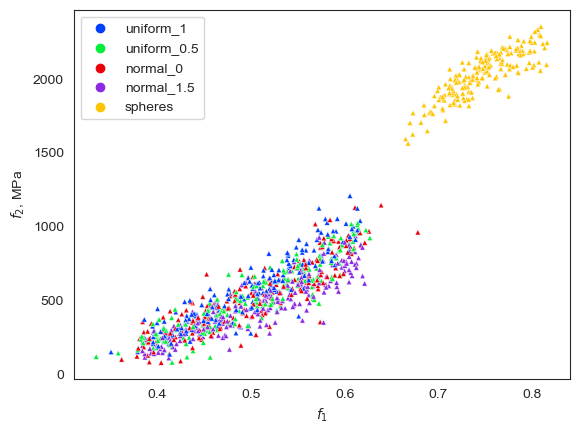

In [17]:
fig, ax = plt.subplots(dpi=dpi)
sns.scatterplot(
    ax=ax,
    data=train_ds_info.sample(1000, random_state=1),
    x="volume_fraction",
    y="young_module",
    hue="class",
    s=15.0,
    marker="^",
)
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend(title="")

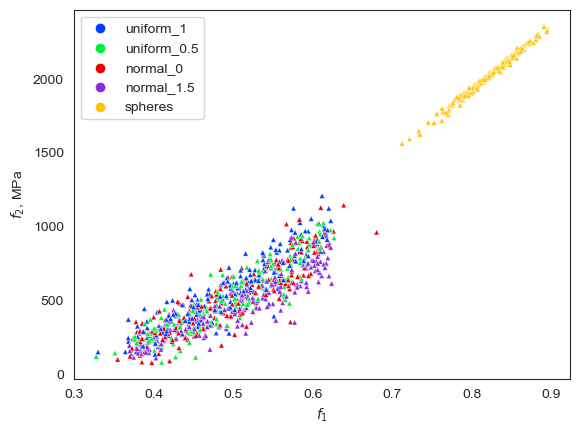

In [18]:
fig, ax = plt.subplots(dpi=dpi)
sns.scatterplot(
    ax=ax,
    data=train_ds_info.sample(1000, random_state=1),
    x="fem_volume_fraction",
    y="young_module",
    hue="class",
    s=15.0,
    marker="^",
)
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend(title="")

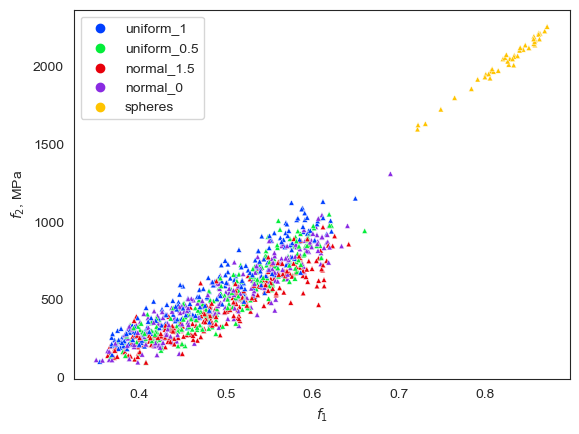

In [19]:
fig, ax = plt.subplots(dpi=dpi)
sns.scatterplot(
    ax=ax,
    data=train_ds_info[train_ds_info["volume_fraction_error"] < 6].sample(1000, random_state=2),
    x="fem_volume_fraction",
    y="young_module",
    hue="class",
    s=15.0,
    marker="^",
)
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend(title="")

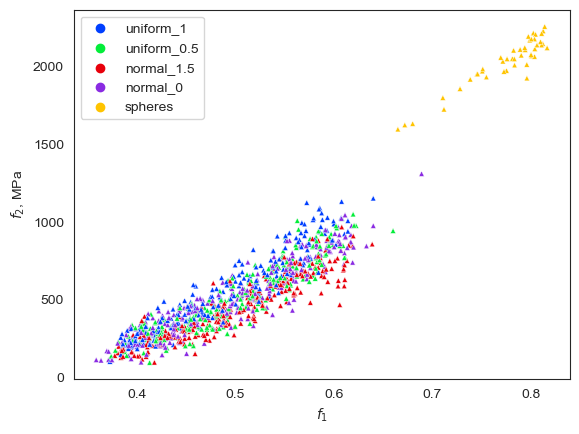

In [20]:
fig, ax = plt.subplots(dpi=dpi)
sns.scatterplot(
    ax=ax,
    data=train_ds_info[train_ds_info["volume_fraction_error"] < 6].sample(1000, random_state=2),
    x="volume_fraction",
    y="young_module",
    hue="class",
    s=15.0,
    marker="^",
)
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend(title="")